# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">Kalkstein 70°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 1609
Average Fx in the averaging interval [260:1869]: 5.847357838430932
Average Fz in the averaging interval [260:1869]: 2.00848937697457
Maximum Fz in the plotting interval [260:None]: 3.9335286458333334 at timestep 1861
Time step where Fx drops below 1: 1869


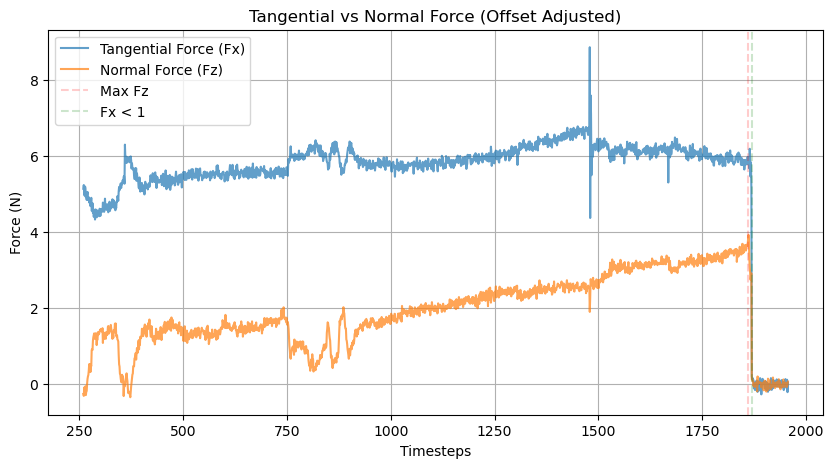

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_70_5N//log_202405231925.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=260, cut_2=None, avg_end=1869, offset_position='end', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 953
Average Fx in the averaging interval [642:1595]: 5.2685076374655715
Average Fz in the averaging interval [642:1595]: 1.6443007809084251
Maximum Fz in the plotting interval [642:None]: 2.8940999348958334 at timestep 1588
Time step where Fx drops below 1: 1596


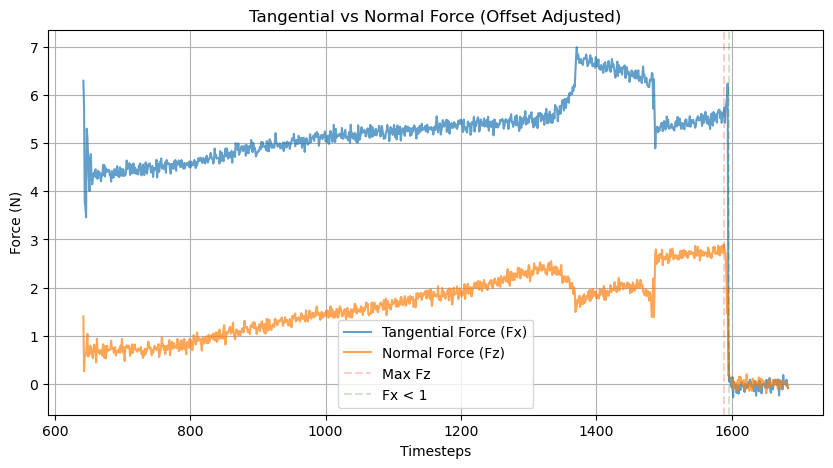

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_70_5N//log_202405231926.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=642, cut_2=None, avg_end=1595, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 844
Average Fx in the averaging interval [1640:2484]: 5.703509870479457
Average Fz in the averaging interval [1640:2484]: 1.3306754509080643
Maximum Fz in the plotting interval [1640:None]: 3.0598461914062502 at timestep 2482
Time step where Fx drops below 1: 2484


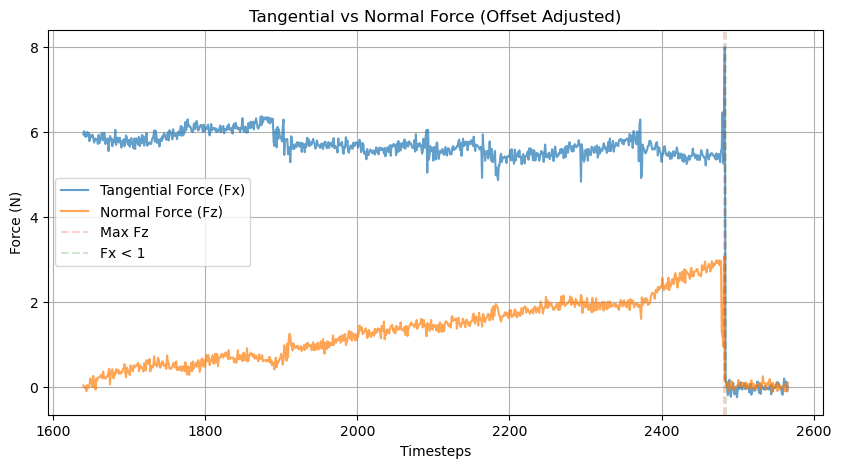

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_70_5N//log_202405231928.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=1640, cut_2=None, avg_end=2484, offset_position='end', offset_length=25)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 832
Average Fx in the averaging interval [615:1447]: 5.659217061866552
Average Fz in the averaging interval [615:1447]: 1.4337828905154497
Maximum Fz in the plotting interval [615:None]: 3.1969278971354167 at timestep 1438
Time step where Fx drops below 1: 1449


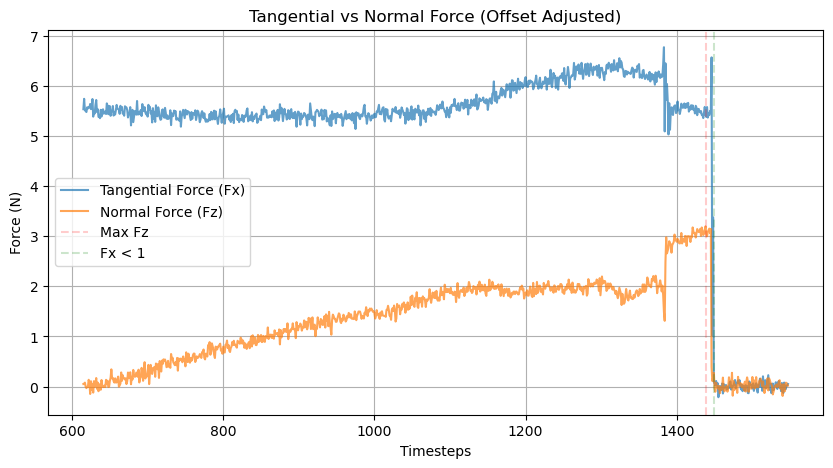

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_70_5N//log_202405231930.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=615, cut_2=None, avg_end=1447, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 926
Average Fx in the averaging interval [610:1536]: 5.672005568450093
Average Fz in the averaging interval [610:1536]: 1.6112162667611591
Maximum Fz in the plotting interval [610:None]: 3.2147989908854164 at timestep 1531
Time step where Fx drops below 1: 1536


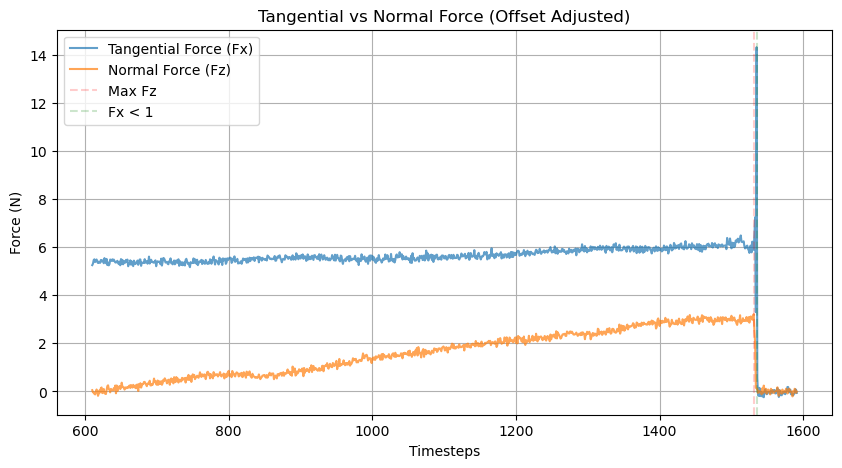

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_70_5N//log_202405231931.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=610, cut_2=None, avg_end=1536, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 1323
Average Fx in the averaging interval [290:1613]: 5.321942924966618
Average Fz in the averaging interval [290:1613]: 1.483192864819539
Maximum Fz in the plotting interval [290:None]: 3.2563883463541665 at timestep 1599
Time step where Fx drops below -0.2: 1613


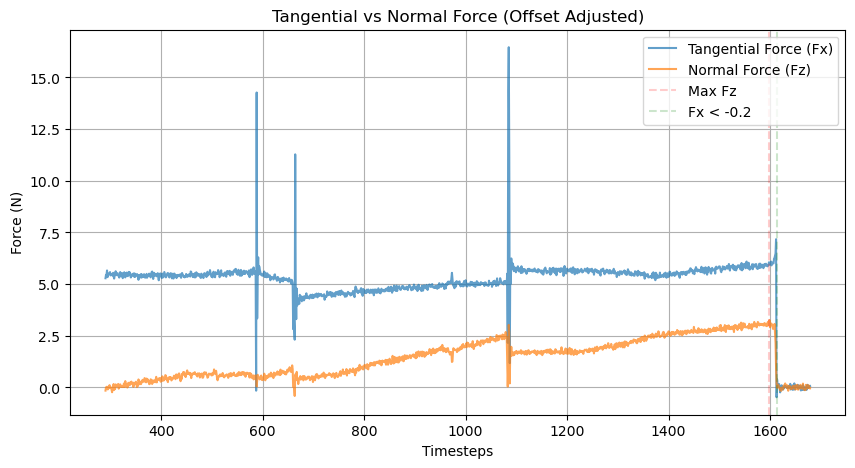

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_70_5N//log_202405231932.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=290, cut_2=None, avg_end=1613, offset_position='end', offset_length=15, fx_threshold=-0.2)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 1055
Average Fx in the averaging interval [450:1505]: 5.688189416285752
Average Fz in the averaging interval [450:1505]: 1.536780614385861
Maximum Fz in the plotting interval [450:None]: 3.1485270182291667 at timestep 1501
Time step where Fx drops below 1: 1505


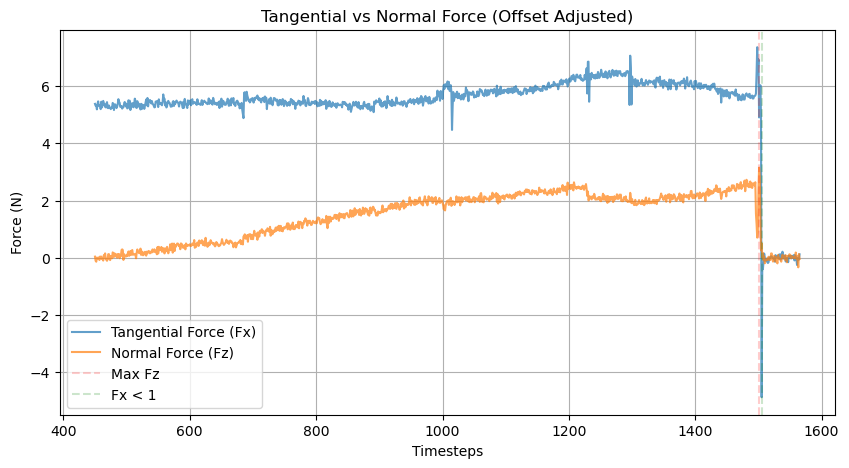

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_70_5N//log_202405231933.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=450, cut_2=None, avg_end=1505, offset_position='end', offset_length=15)

<font size="6">Test 8: (partially worked / failed)</font>

Length from cut_1 to avg_end: 72
Average Fx in the averaging interval [845:917]: 5.558139272530874
Average Fz in the averaging interval [845:917]: 0.07880198160807289
Maximum Fz in the plotting interval [845:None]: 0.3004231770833333 at timestep 893
Time step where Fx drops below 1: 917


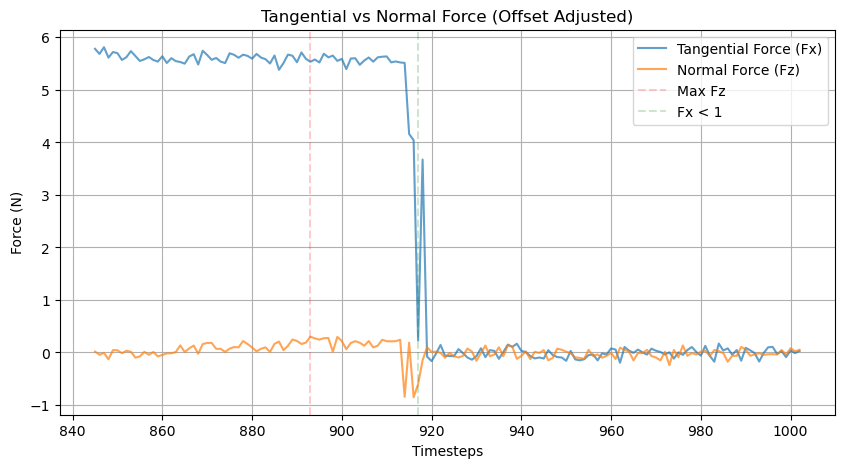

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_70_5N//log_202405231935.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=845, cut_2=None, avg_end=917, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 437
Average Fx in the averaging interval [830:1267]: 5.919217200173757
Average Fz in the averaging interval [830:1267]: 0.7833512015964673
Maximum Fz in the plotting interval [830:None]: 1.62906494140625 at timestep 1241
Time step where Fx drops below 1: 1268


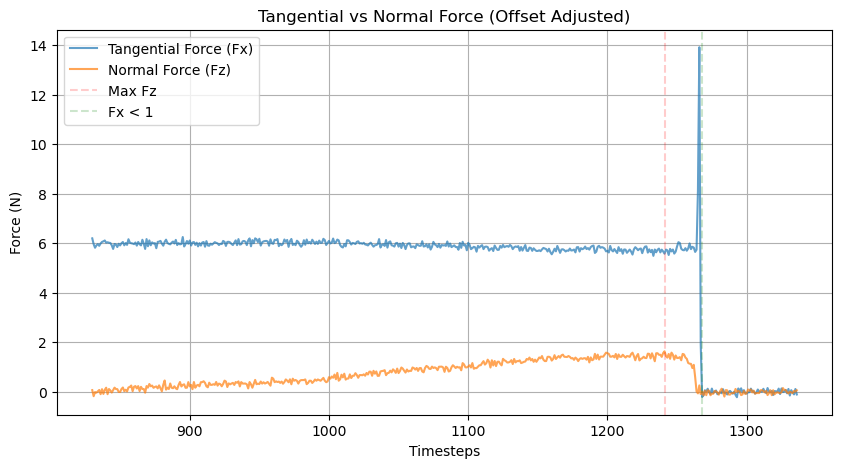

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_70_5N//log_202405231936.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=830, cut_2=None, avg_end=1267, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 884
Average Fx in the averaging interval [560:1444]: 5.558750406901042
Average Fz in the averaging interval [560:1444]: 1.50570068359375
Maximum Fz in the plotting interval [560:None]: 2.98922119140625 at timestep 1405
Time step where Fx drops below -0.04: 1444


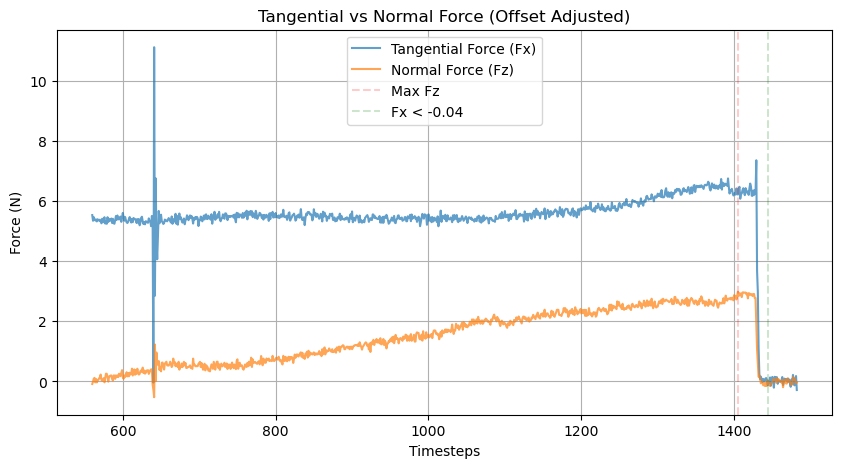

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_70_5N//log_202405231937.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=560, cut_2=None, avg_end=1444, offset_position='end', offset_length=15, fx_threshold=-0.04)

In [13]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [17]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//70//Kalkstein_70_stats.csv", index=False)

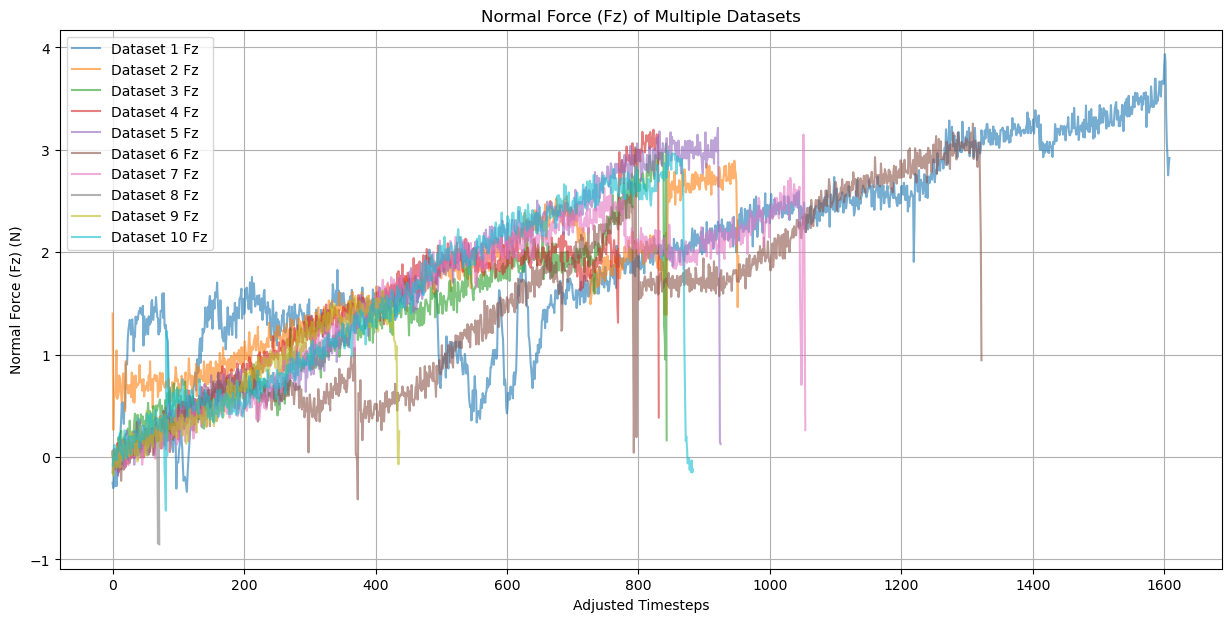

Average of maximum Fz forces: 2.7622826334635415
Standard deviation of maximum Fz forces: 0.9829132852061195
Average of average Fz forces: 1.341629211207136
Standard deviation of average Fz forces: 0.5107888761376244
Average of average Fx forces: 5.619683719755065
Standard deviation of average Fx forces: 0.19417799423500914


In [18]:
tests = [test_1, test_2, test_3, test_4, test_5, test_6, test_7, test_8, test_9, test_10]
ends = [end_1, end_2, end_3, end_4, end_5, end_6, end_7, end_8, end_9, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [19]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//70//Kalkstein_70"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)